# Image Thresholding

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [22]:
img = cv2.imread('rainbow.jpg')

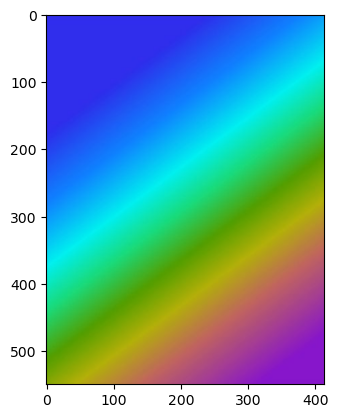

In [23]:
plt.imshow(img)

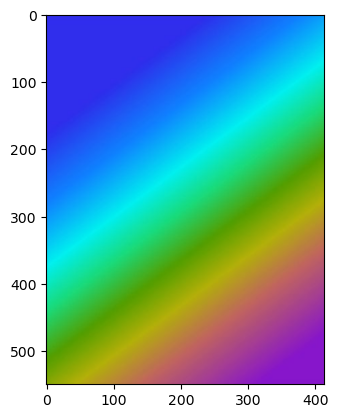

In [24]:
plt.imshow(img,cmap='gray')

In [31]:
# Adding the 0 flag to read it in black and white
imgflag = cv2.imread('rainbow.jpg',0)
# why do we have to do this?

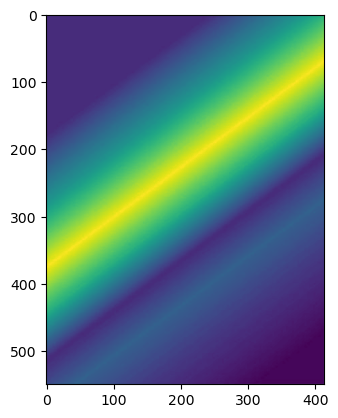

In [32]:
plt.imshow(imgflag)

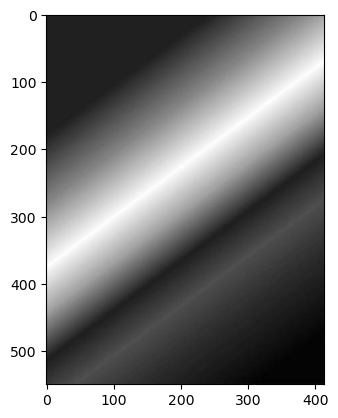

In [33]:
plt.imshow(imgflag,cmap='gray')

In [34]:
imgflag.max()

214

## Different Threshold Types

### Binary

In [36]:
ret,thresh1 = cv2.threshold(imgflag,127,255,cv2.THRESH_BINARY)

In [38]:
thresh1

array([[  0,   0,   0, ..., 255, 255, 255],
       [  0,   0,   0, ..., 255, 255, 255],
       [  0,   0,   0, ..., 255, 255, 255],
       ...,
       [  0,   0,   0, ...,   0,   0,   0],
       [  0,   0,   0, ...,   0,   0,   0],
       [  0,   0,   0, ...,   0,   0,   0]], dtype=uint8)

In [37]:
ret

127.0

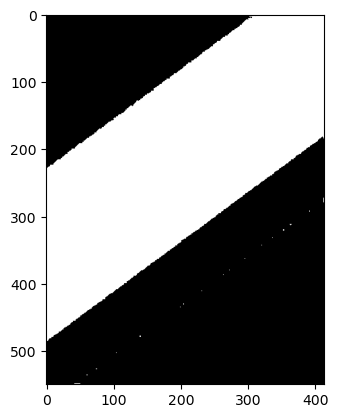

In [39]:
plt.imshow(thresh1,cmap='gray')

### Binary Inverse

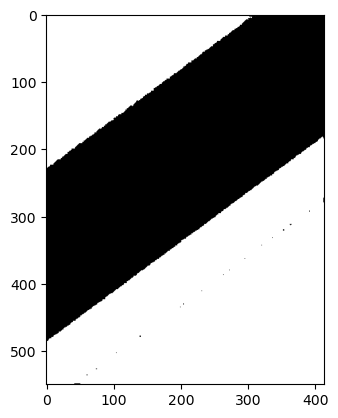

In [40]:
ret,thresh2 = cv2.threshold(imgflag,127,255,cv2.THRESH_BINARY_INV)
plt.imshow(thresh2,cmap='gray')

###  Threshold Truncation

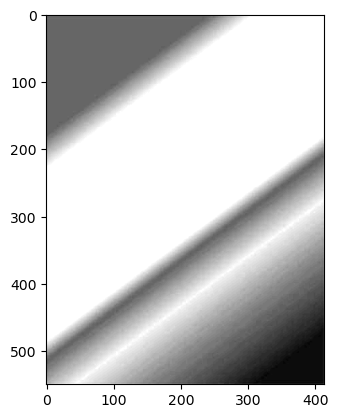

In [41]:
ret,thresh3 = cv2.threshold(imgflag,127,255,cv2.THRESH_TRUNC)
plt.imshow(thresh3,cmap='gray')

### Threshold to Zero

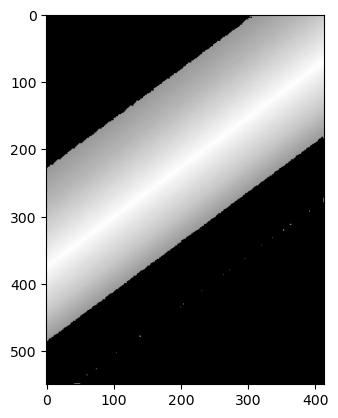

In [11]:
ret,thresh4 = cv2.threshold(imgflag,127,255,cv2.THRESH_TOZERO)
plt.imshow(thresh4,cmap='gray')

### Threshold to Zero (Inverse)

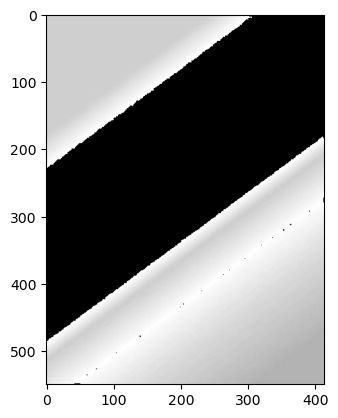

In [12]:
ret,thresh5 = cv2.threshold(imgflag,127,255,cv2.THRESH_TOZERO_INV)
plt.imshow(thresh5,cmap='gray')

# Real World Applications

## Adaptive Thresholding



### Sudoku Image

In [13]:
imgcross = cv2.imread("crossword.jpg",0)

In [14]:
def show_pic(imgcross):
    fig = plt.figure(figsize=(15,15))
    ax = fig.add_subplot(111)
    ax.imshow(imgcross,cmap='gray')

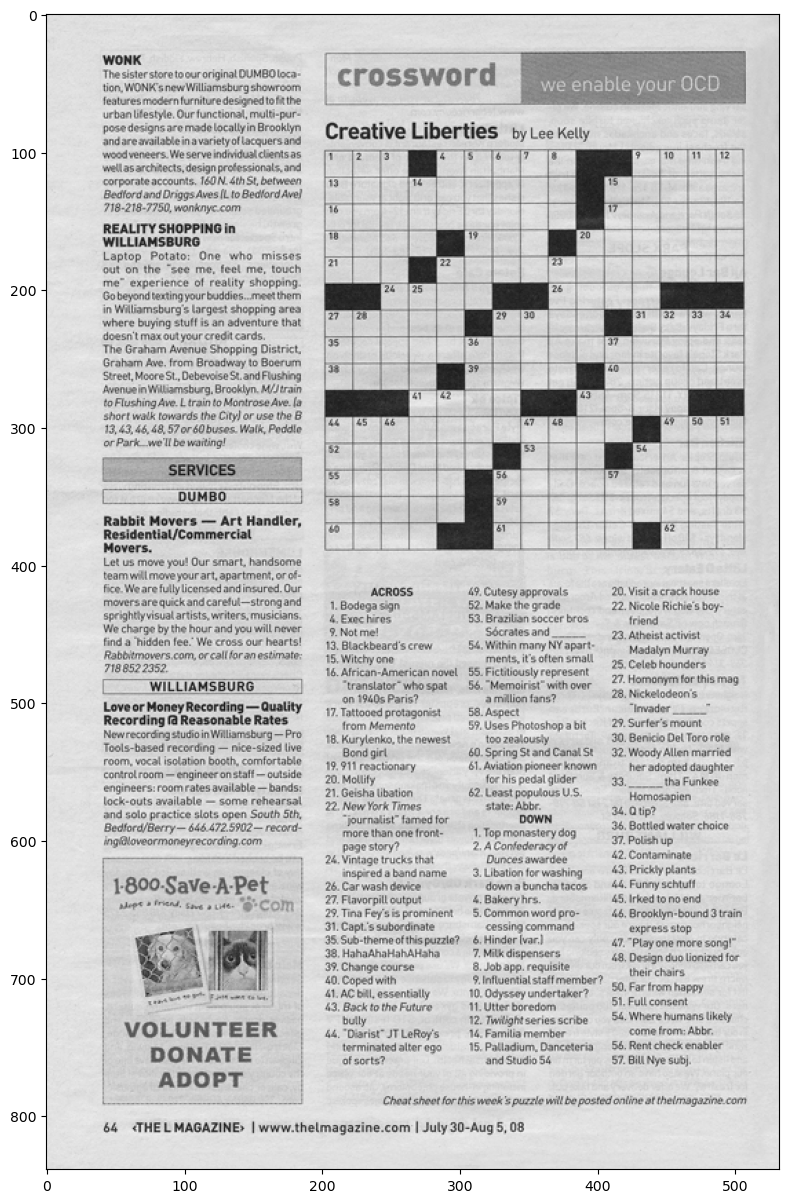

In [15]:
show_pic(imgcross)

## Simple Binary

In [16]:
ret,th1 = cv2.threshold(imgcross,127,255,cv2.THRESH_BINARY)

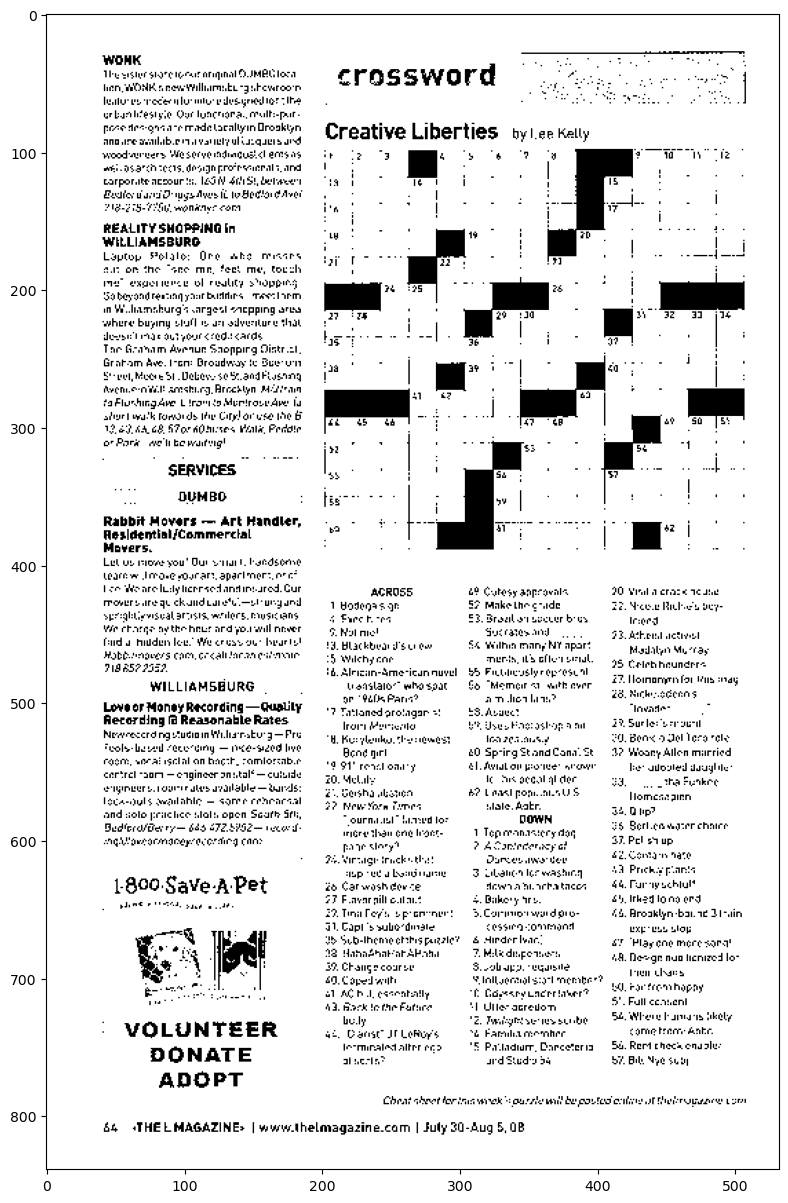

In [17]:
show_pic(th1)

### Adaptive Threshold

https://stackoverflow.com/questions/28763419/adaptive-threshold-parameters-confusion

    @param src Source 8-bit single-channel image.
    .   @param dst Destination image of the same size and the same type as src.
    .   @param maxValue Non-zero value assigned to the pixels for which the condition is satisfied
    .   @param adaptiveMethod Adaptive thresholding algorithm to use, see #AdaptiveThresholdTypes.
    .   The #BORDER_REPLICATE | #BORDER_ISOLATED is used to process boundaries.
    .   @param thresholdType Thresholding type that must be either #THRESH_BINARY or #THRESH_BINARY_INV,
    .   see #ThresholdTypes.
    .   @param blockSize Size of a pixel neighborhood that is used to calculate a threshold value for the
    .   pixel: 3, 5, 7, and so on.
    .   @param C Constant subtracted from the mean or weighted mean (see the details below). Normally, it
    .   is positive but may be zero or negative as well.

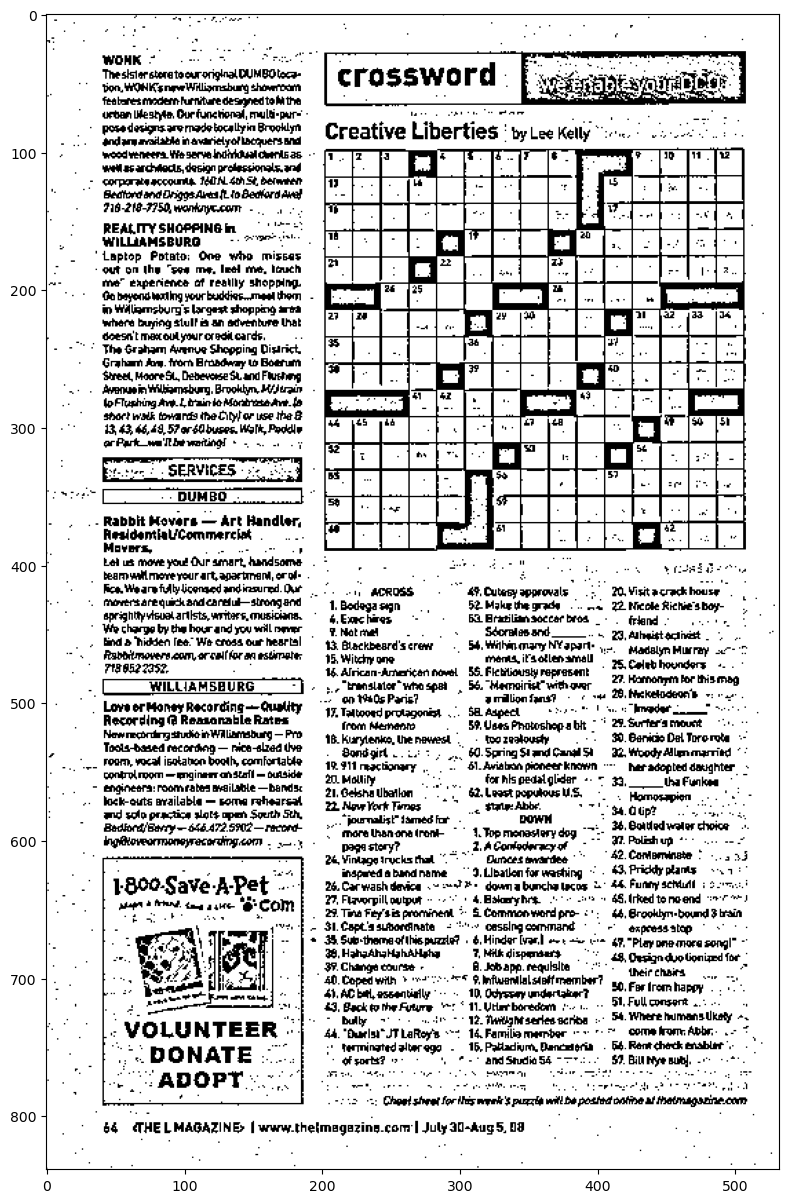

In [18]:
th2 = cv2.adaptiveThreshold(imgcross,255,cv2.ADAPTIVE_THRESH_MEAN_C,cv2.THRESH_BINARY,11,8) # Play around with these last 2 numbers
show_pic(th2)

In [19]:
th3 = cv2.adaptiveThreshold(imgcross,255,cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY,15,8)

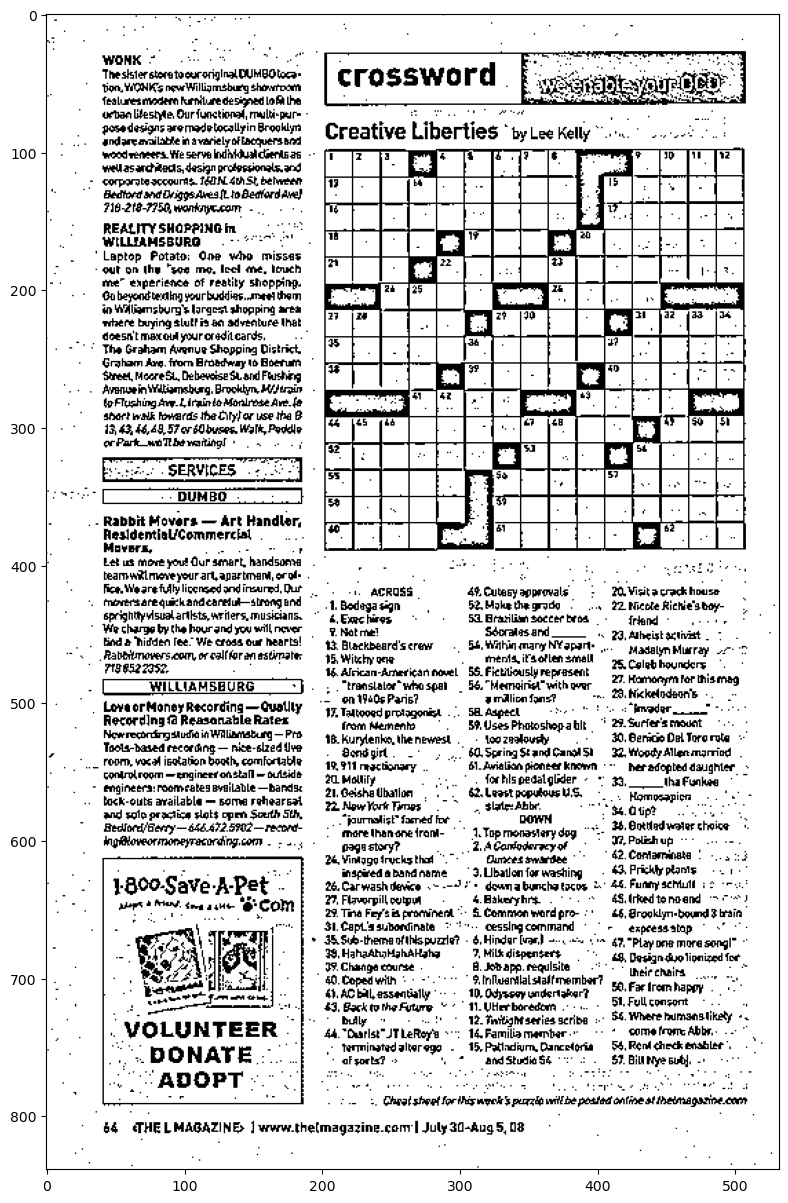

In [20]:
show_pic(th3)

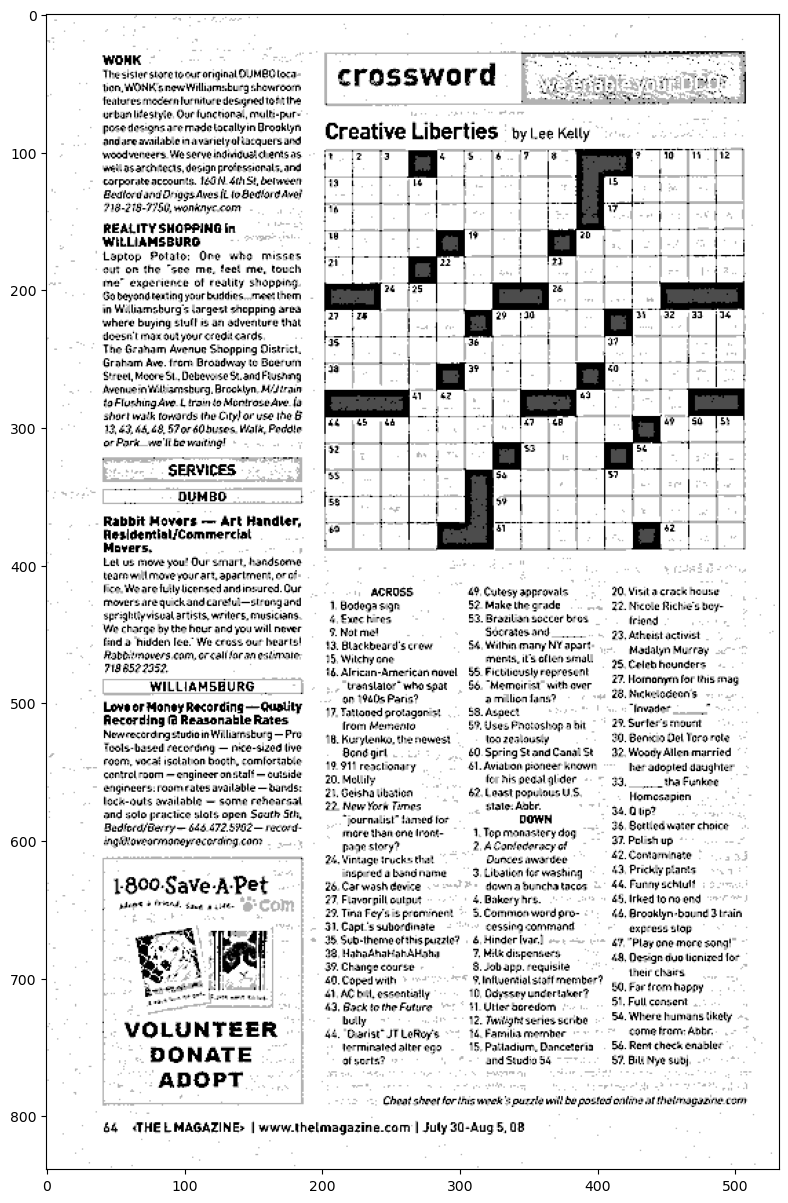

In [21]:
blended = cv2.addWeighted(src1=th1,alpha=0.7,src2=th2,beta=0.3,gamma=0)
show_pic(blended)